# BBC News Classification - TF-IDF Workflow

Notebook này được sắp xếp theo workflow: load data -> data quality -> EDA -> cleaning -> artifact export -> split -> TF-IDF -> model training -> cross-validation -> diagnostics.

## 1. Import Libraries

In [1]:
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


## 2. Load Raw Text Data

In [2]:
data = []
path = "."

for category in sorted(os.listdir(path)):
    category_path = os.path.join(path, category)
    if not os.path.isdir(category_path):
        continue

    for file in sorted(os.listdir(category_path)):
        file_path = os.path.join(category_path, file)
        if file.endswith(".txt"):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()
                data.append({
                    "doc_id": f"{category}_{file.replace('.txt', '')}",
                    "filepath": file_path,
                    "category": category,
                    "text": text,
                })

df = pd.DataFrame(data)
df.head()


,doc_id,filepath,category,text
0,business_001,./business/001.txt,business,Ad sales boost Time Warner profit\n\nQuarterly...
1,business_002,./business/002.txt,business,Dollar gains on Greenspan speech\n\nThe dollar...
2,business_003,./business/003.txt,business,Yukos unit buyer faces loan claim\n\nThe owner...
3,business_004,./business/004.txt,business,High fuel prices hit BA's profits\n\nBritish A...
4,business_005,./business/005.txt,business,Pernod takeover talk lifts Domecq\n\nShares in...


## 3. Data Quality Checks

In [3]:
print("Total samples:", len(df))
print("Empty text:", df["text"].str.strip().eq("").sum())
print("Duplicate text:", df.duplicated(subset=["text"]).sum())
print("Missing category:", df["category"].isna().sum())

label_counts = df["category"].value_counts().sort_index()
print("\nLabel counts:")
print(label_counts)
print("\nLabel percentage:")
print((label_counts / len(df) * 100).round(2))


Total samples: 2225
Empty text: 0
Duplicate text: 98
Missing category: 0

Label counts:
category
business         510
entertainment    386
politics         417
sport            511
tech             401
Name: count, dtype: int64

Label percentage:
category
business         22.92
entertainment    17.35
politics         18.74
sport            22.97
tech             18.02
Name: count, dtype: float64


## 4. Exploratory Data Analysis

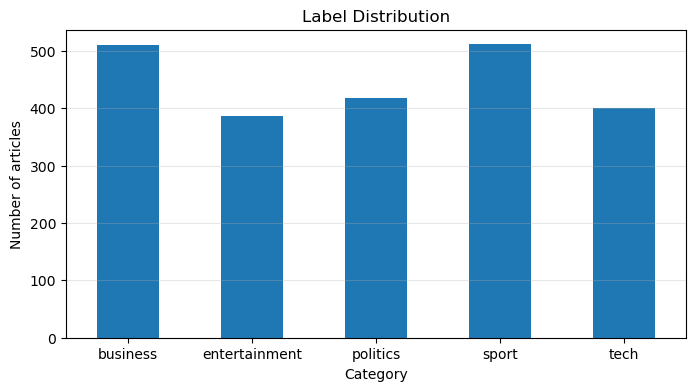

In [4]:
label_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Label Distribution")
plt.xlabel("Category")
plt.ylabel("Number of articles")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64


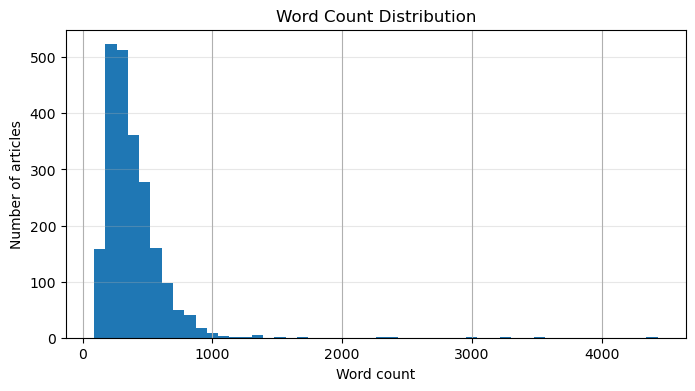

In [5]:
df["word_count"] = df["text"].apply(lambda text: len(str(text).split()))
print(df["word_count"].describe())

df["word_count"].hist(bins=50, figsize=(8, 4))
plt.title("Word Count Distribution")
plt.xlabel("Word count")
plt.ylabel("Number of articles")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [6]:
df.groupby("category")["word_count"].mean().sort_values(ascending=False)


category
tech             502.695761
politics         453.973621
entertainment    330.621762
sport            329.262231
business         328.880392
Name: word_count, dtype: float64

## 5. Text Cleaning

In [7]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    text = str(text).lower()
    text = re.sub(r"([.,!?])(?=[^\s])", r"\1 ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    words = text.split()
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(clean_words)

df["clean_text"] = df["text"].apply(clean_and_lemmatize)
df["clean_word_count"] = df["clean_text"].apply(lambda text: len(str(text).split()))

print("Before preprocessing:\n", df["text"].iloc[0][:500])
print("\nAfter preprocessing:\n", df["clean_text"].iloc[0][:500])
print("\nClean word count summary:")
print(df["clean_word_count"].describe())


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/luongnhatkhoi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/luongnhatkhoi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/luongnhatkhoi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Before preprocessing:
 Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time W

After preprocessing:
 ad sale boost time warner profit quarterly profit u medium giant timewarner jumped 76 1 13bn 600m three month december 639m year earlier firm one biggest investor google benefited sale high speed internet connection higher advert sale timewarner said fourth quarter sale rose 2 11 1bn 10 9bn profit buoyed one gain offset profit dip warner bros less user aol time warner said friday owns 8 search engine google internet business aol mixed fortune lost 4

## 6. Label Encoding and Artifact Export

In [8]:
label_mapping = {
    label: idx
    for idx, label in enumerate(sorted(df["category"].unique()))
}

df["label_id"] = df["category"].map(label_mapping)

with open("label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)

df.to_csv("bbc_clean.csv", index=False, encoding="utf-8")

label_mapping


{'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}

## 7. Stratified Train / Validation / Test Split

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_id"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"],
    random_state=42,
)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (1557, 8)
Validation shape: (334, 8)
Test shape: (334, 8)


## 8. TF-IDF Vectorization

In [10]:
tfidf_config = {
    "ngram_range": [1, 2],
    "min_df": 2,
    "max_df": 0.85,
    "sublinear_tf": True,
    "norm": "l2",
    "fit_on": "train only",
}

with open("tfidf_config.json", "w") as f:
    json.dump(tfidf_config, f, indent=2)

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    norm="l2",
)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_val = tfidf.transform(val_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


Number of TF-IDF features: 54037
X_train shape: (1557, 54037)
X_val shape: (334, 54037)
X_test shape: (334, 54037)


In [11]:
feature_names = tfidf.get_feature_names_out()
sample_vector = X_train[0]
top_indices = sample_vector.toarray()[0].argsort()[-20:][::-1]

for idx in top_indices:
    if sample_vector[0, idx] > 0:
        print(feature_names[idx], sample_vector[0, idx])


connors 0.22126593868705946
said connors 0.14640995797451206
tennis 0.14471781365430675
lta 0.1360977229677035
fine line 0.11812263222177714
tennis association 0.11343713778539118
andrew murray 0.1098027859493956
everybody 0.10529063243993529
one number 0.10432264330703024
henman 0.09851345801028803
long time 0.09190962450756646
murray 0.09085848190717603
attitude 0.0880595469027839
three day 0.08117245308765905
relationship 0.07365849134970025
britain 0.07186668114930567
fine 0.07166166028839761
52 year 0.06976512944534005
place one 0.06976512944534005
relationship lawn 0.06976512944534005


## 9. Baseline Model Training

In [12]:
y_train = train_df["label_id"]
y_val = val_df["label_id"]
y_test = test_df["label_id"]

models = {
    "Dummy majority baseline": DummyClassifier(strategy="most_frequent"),
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(random_state=42),
}

results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    results.append({
        "model": model_name,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "val_weighted_f1": f1_score(y_val, val_pred, average="weighted"),
    })
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
results_df


,model,val_accuracy,val_macro_f1,val_weighted_f1
3,LinearSVC,0.982036,0.981482,0.982052
2,LogisticRegression,0.973054,0.972299,0.973108
1,MultinomialNB,0.973054,0.971822,0.973050
0,Dummy majority baseline,0.227545,0.074146,0.084358


## 10. Test Evaluation

In [13]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
test_pred = best_model.predict(X_test)

target_names = [label for label, _ in sorted(label_mapping.items(), key=lambda item: item[1])]

print("Best model:", best_model_name)
print("Test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test macro F1:", round(f1_score(y_test, test_pred, average="macro"), 4))
print("\nClassification report:\n")
print(classification_report(y_test, test_pred, target_names=target_names))
print("Confusion matrix:\n")
print(confusion_matrix(y_test, test_pred))


Best model: LinearSVC
Test accuracy: 0.988
Test macro F1: 0.9886

Classification report:

               precision    recall  f1-score   support

     business       0.99      0.96      0.97        77
entertainment       1.00      1.00      1.00        58
     politics       0.97      0.98      0.98        62
        sport       0.99      1.00      0.99        77
         tech       1.00      1.00      1.00        60

     accuracy                           0.99       334
    macro avg       0.99      0.99      0.99       334
 weighted avg       0.99      0.99      0.99       334

Confusion matrix:

[[74  0  2  1  0]
 [ 0 58  0  0  0]
 [ 1  0 61  0  0]
 [ 0  0  0 77  0]
 [ 0  0  0  0 60]]


## 11. StratifiedKFold Cross Validation

In [14]:
X_text = df["clean_text"]
y = df["label_id"]

tfidf_params = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.85,
    "sublinear_tf": True,
    "norm": "l2",
}

cv_models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(random_state=42),
}

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for model_name, model in cv_models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", model),
    ])
    scores = cross_validate(
        pipeline,
        X_text,
        y,
        cv=stratified_cv,
        scoring=["accuracy", "f1_macro", "f1_weighted"],
        n_jobs=-1,
    )
    cv_results.append({
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        "cv_macro_f1_std": scores["test_f1_macro"].std(),
        "cv_weighted_f1_mean": scores["test_f1_weighted"].mean(),
        "cv_weighted_f1_std": scores["test_f1_weighted"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean", ascending=False)
cv_results_df


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std
2,LinearSVC,0.983820,0.003303,0.983565,0.003500,0.983830,0.003326
1,LogisticRegression,0.980674,0.004404,0.980231,0.004607,0.980658,0.004452
0,MultinomialNB,0.966292,0.007521,0.965599,0.007276,0.966277,0.007426


## 12. Overfitting / High Bias Diagnostics

/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
5 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-pac

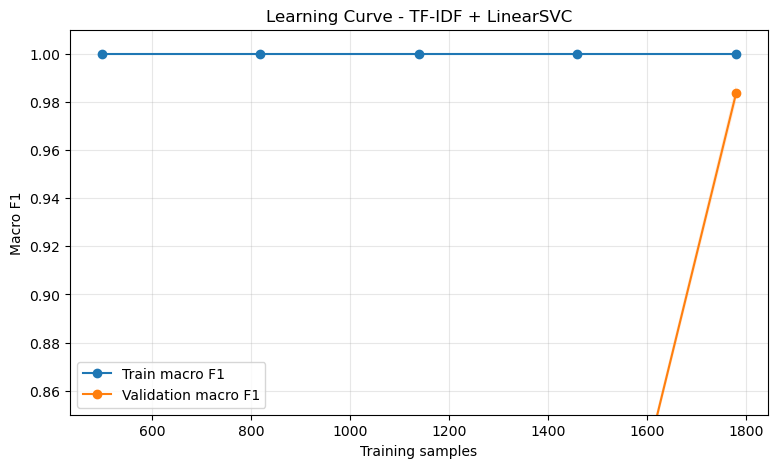

Final train macro F1: 1.0
Final validation macro F1: 0.9836
Final train-validation gap: 0.0164
Diagnosis: no strong overfitting/high-bias signal


In [15]:
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("model", LinearSVC(random_state=42)),
])

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline,
    X_text,
    y,
    cv=stratified_cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Train macro F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, marker="o", label="Validation macro F1")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.title("Learning Curve - TF-IDF + LinearSVC")
plt.xlabel("Training samples")
plt.ylabel("Macro F1")
plt.ylim(0.85, 1.01)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print("Final train macro F1:", round(train_mean[-1], 4))
print("Final validation macro F1:", round(val_mean[-1], 4))
print("Final train-validation gap:", round(gap, 4))

if val_mean[-1] < 0.80 and train_mean[-1] < 0.85:
    print("Diagnosis: possible high bias / underfitting")
elif gap > 0.05:
    print("Diagnosis: possible overfitting")
else:
    print("Diagnosis: no strong overfitting/high-bias signal")


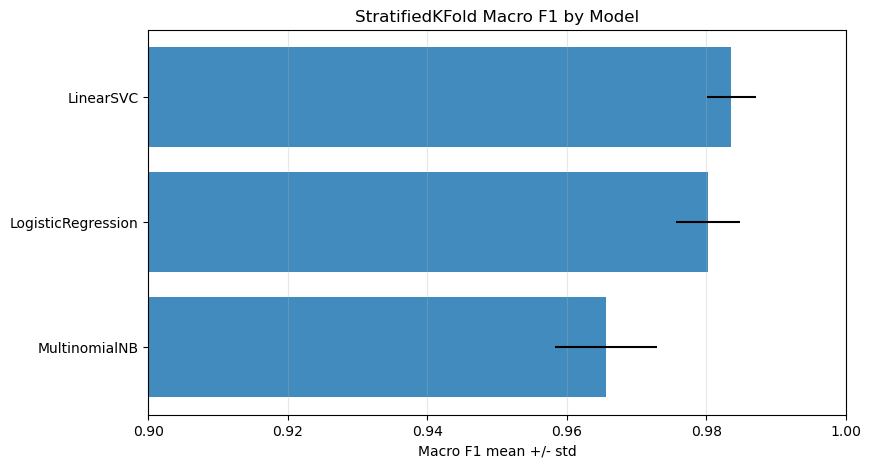

,model,cv_macro_f1_mean,cv_macro_f1_std,cv_accuracy_mean,cv_accuracy_std
2,LinearSVC,0.983565,0.003500,0.983820,0.003303
1,LogisticRegression,0.980231,0.004607,0.980674,0.004404
0,MultinomialNB,0.965599,0.007276,0.966292,0.007521


In [16]:
plot_df = cv_results_df.sort_values("cv_macro_f1_mean", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["cv_macro_f1_mean"], xerr=plot_df["cv_macro_f1_std"], alpha=0.85)
plt.title("StratifiedKFold Macro F1 by Model")
plt.xlabel("Macro F1 mean +/- std")
plt.xlim(0.90, 1.0)
plt.grid(axis="x", alpha=0.3)
plt.show()

cv_results_df[["model", "cv_macro_f1_mean", "cv_macro_f1_std", "cv_accuracy_mean", "cv_accuracy_std"]]


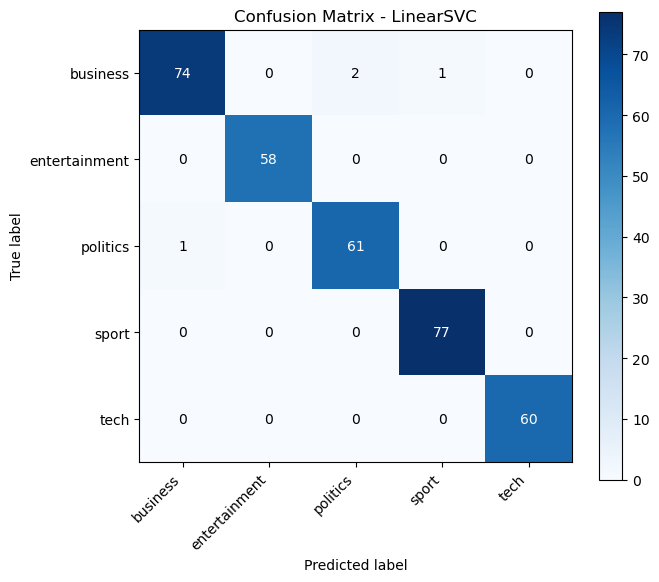

In [17]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 13. Notes

- `StratifiedKFold` is preferred because this is a multi-class classification task.
- TF-IDF must be fitted on train data only to avoid leakage.
- The earlier `max_features=5000` version is useful only as a quick dummy baseline, not as the final evaluation pipeline.